In [1]:
import sys
sys.path.append('../src')

from preprocess import load_and_clean, encode, split, save_columns
from train import (
    get_scale_pos_weight, train_baseline,
    train_xgboost, evaluate, plot_results
)
import joblib
import os

In [2]:
# Pipeline de dados
df = load_and_clean('../data/telco_churn.csv')
df = encode(df)
X_train, X_test, y_train, y_test = split(df)
save_columns(X_train, '../models/feature_columns.pkl')

print(f"scale_pos_weight: {get_scale_pos_weight(y_train):.2f}")
# Esperado: ~2.77 — modelo vai dar ~2.77x mais peso aos churns

Colunas salvas em ../models/feature_columns.pkl - total: 23 features
scale_pos_weight: 2.77


In [3]:
print(X_train.dtypes.value_counts())
print(X_train.select_dtypes(include='object').columns.tolist())

int32      14
int64       7
float64     2
Name: count, dtype: int64
[]


In [4]:
# Baseline
baseline = train_baseline(X_train, y_train)
evaluate(baseline, X_test, y_test, "Logistic Regression")


Avaliação do modelo: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

       Ficou       0.85      0.89      0.87      1035
     Churnou       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409


AUC-ROC: 0.8427


c:\Users\mathe\Desktop\Churn\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(array([0, 1, 0, ..., 0, 0, 0], dtype=int64),
 array([0.0463634 , 0.68617059, 0.06448169, ..., 0.16008577, 0.00424954,
        0.00648999]))

In [5]:
# XGBoost
xgb_model = train_xgboost(X_train, y_train, X_test, y_test)
evaluate(xgb_model, X_test, y_test, "XGBoost")

[0]	validation_0-auc:0.81870
[50]	validation_0-auc:0.84324
[92]	validation_0-auc:0.84367

Avaliação do modelo: XGBoost

Classification Report:
              precision    recall  f1-score   support

       Ficou       0.92      0.72      0.81      1035
     Churnou       0.52      0.82      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


AUC-ROC: 0.8446


(array([0, 1, 0, ..., 0, 0, 0]),
 array([0.04676791, 0.85897464, 0.14514133, ..., 0.30791137, 0.05459018,
        0.03612242], dtype=float32))


Gráficos salvos em assets/model_evaluation.png


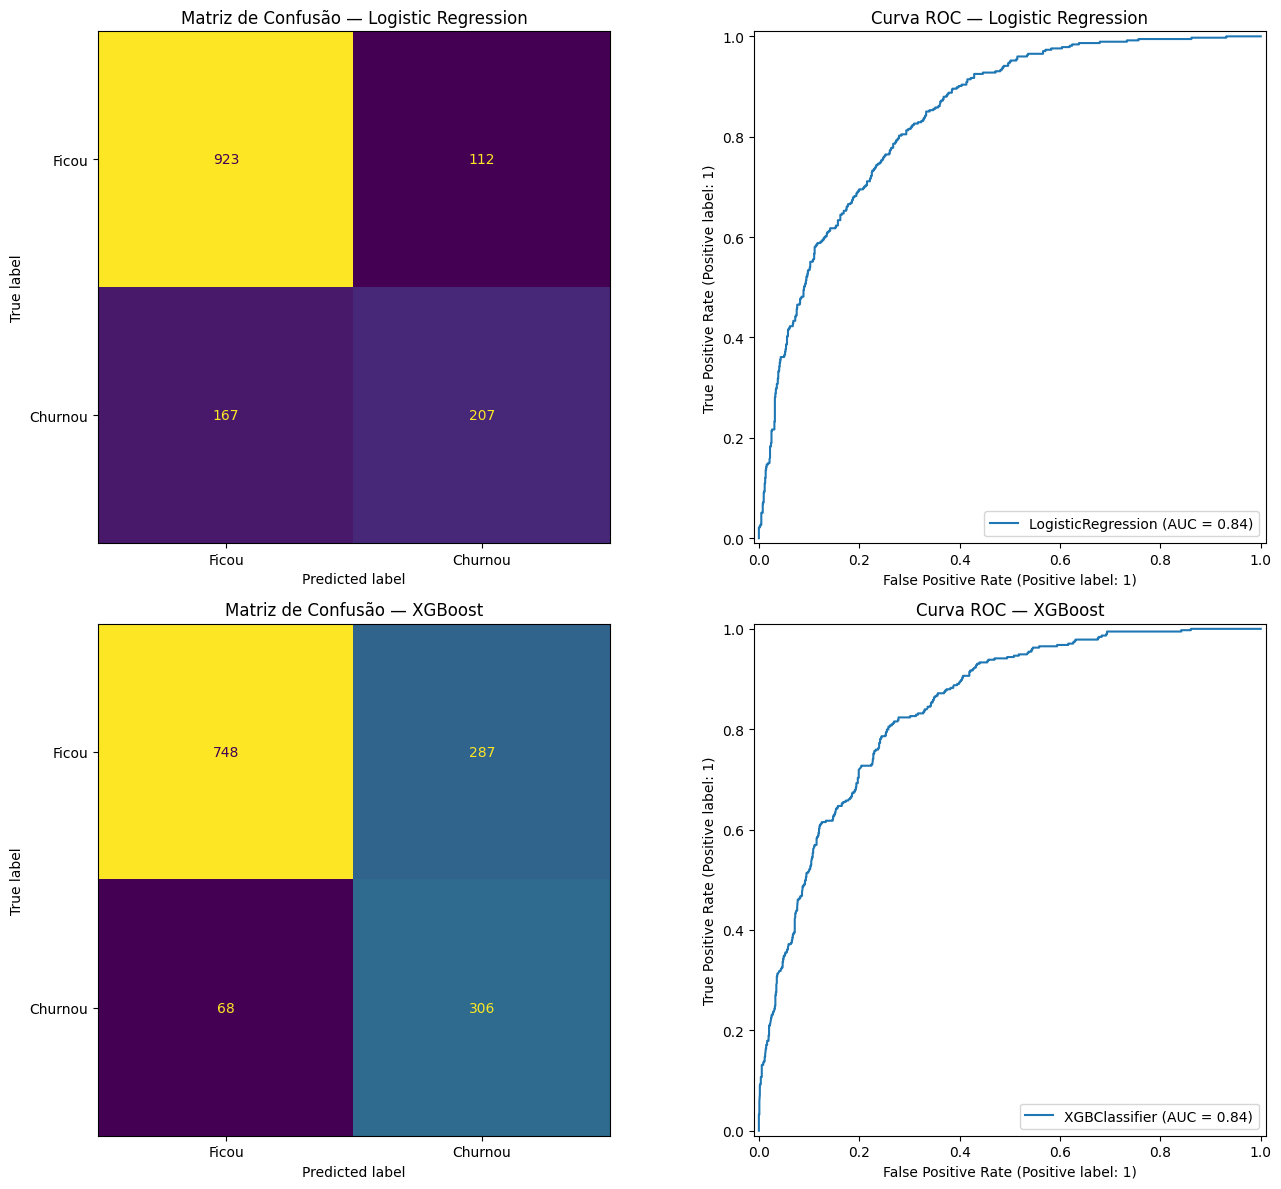

In [6]:
# Plots comparativos
plot_results(
    [("Logistic Regression", baseline), ("XGBoost", xgb_model)],
    X_test, y_test
)

In [7]:
# Salva o modelo
os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_model, '../models/xgb_model.pkl')
print("Modelo salvo.")

Modelo salvo.
